<a href="https://colab.research.google.com/github/j019/Practical-Machine-Learning/blob/main/Day4/FeatureSelection_EmployeeAttrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [129]:
import pandas as pd
import numpy as np

In [130]:
df = pd.read_csv('/content/EmployeeAttrition.csv')

In [131]:
df.shape

(1470, 35)

In [132]:
df.isna().sum().sum()

np.int64(0)

In [133]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [134]:
df.columns[df.nunique() == 1]

Index(['EmployeeCount', 'Over18', 'StandardHours'], dtype='object')

In [135]:
df.drop(columns=['EmployeeCount','Over18','StandardHours','EmployeeNumber'],inplace=True)

In [136]:
df.drop_duplicates(inplace=True)
df.shape

(1470, 31)

In [137]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']
X.shape, y.shape

((1470, 30), (1470,))

In [138]:
y.unique()

array(['Yes', 'No'], dtype=object)

In [139]:
y.replace({'Yes':1,'No':0},inplace=True)

/tmp/ipykernel_4946/3269030041.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace({'Yes':1,'No':0},inplace=True)


In [140]:
y.unique()

array([1, 0])

In [141]:
y.value_counts(normalize=True)

,proportion
Attrition,
0,0.838776
1,0.161224


In [142]:
df['BusinessTravel'].unique()

array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], dtype=object)

In [143]:
# label encoding -> Business Travel
label_map = {'BusinessTravel':{'Travel_Rarely':1,
                               'Travel_Frequently':2,
                               'Non-Travel':0}}
X.replace(label_map,inplace=True)


/tmp/ipykernel_4946/1974907488.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.replace(label_map,inplace=True)


In [144]:
X['BusinessTravel'].unique()

array([1, 2, 0])

In [145]:
X_ohe = pd.get_dummies(X)
X_ohe.shape

(1470, 49)

In [146]:
cont_col = X.columns[X.nunique() > 15]
cont_col

Index(['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
       'MonthlyRate', 'TotalWorkingYears', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [147]:
# Train - test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_ohe,y,test_size=0.3,
                                                 random_state=7,stratify=y)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1029, 49), (441, 49), (1029,), (441,))

In [148]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[cont_col] = sc.fit_transform(X_train[cont_col])
X_test[cont_col] = sc.transform(X_test[cont_col])
#

In [149]:
X_train.mean()

,0
Age,2.175131e-16
BusinessTravel,1.102041e+00
DailyRate,-1.381035e-16
DistanceFromHome,-8.631472e-17
Education,2.921283e+00
EnvironmentSatisfaction,2.728863e+00
HourlyRate,-2.727545e-16
JobInvolvement,2.719145e+00
JobLevel,2.040816e+00
JobSatisfaction,2.719145e+00


# Apply PCA

In [150]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95,random_state=7)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_train_pca.shape , X_test_pca.shape

((1029, 23), (441, 23))

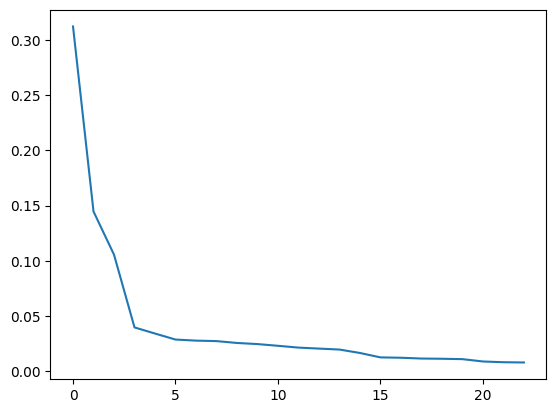

In [151]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)), pca.explained_variance_ratio_)
plt.show()

In [152]:
pca.explained_variance_ratio_

array([0.3123463 , 0.14467177, 0.10552598, 0.03959549, 0.03403417,
       0.02859571, 0.02761114, 0.02718917, 0.02549321, 0.02449288,
       0.02292863, 0.02128999, 0.0203983 , 0.01952879, 0.01641858,
       0.01242995, 0.01209933, 0.01138264, 0.01118213, 0.0108328 ,
       0.0087168 , 0.00803502, 0.00781183])

In [153]:
len(pca.components_),X_train.shape

(23, (1029, 49))

# Kernel PCA

In [154]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(kernel="rbf",random_state=7)
X_train_pca = kpca.fit_transform(X_train)
X_test_pca = kpca.transform(X_test)
X_train_pca.shape , X_test_pca.shape

((1029, 1028), (441, 1028))

# Applying RFE (Supervised Learning)

In [155]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
rfe = RFE(LogisticRegression(random_state=7),verbose=2)
rfe.fit(X_train,y_train)
print(rfe.ranking_)

Fitting estimator with 49 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 48 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 47 features.


...

Fitting estimator with 42 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Fitting estimator with 41 features.
Fitting estimator with 40 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
[10  1 19  2 26  1 24  1 22  1  1 23 11 25 16  6 18 12 17  1  1  1  1  1
 20  7  1  1 15  1  1 14  1 13  5  1  1  1  1  8  1 21  9  1  3  4  1  1
  1]


In [156]:
X_train.columns[rfe.ranking_ == 1]

Index(['BusinessTravel', 'EnvironmentSatisfaction', 'JobInvolvement',
       'JobSatisfaction', 'MonthlyIncome', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Research Director',
       'JobRole_Sales Representative', 'MaritalStatus_Single', 'OverTime_No',
       'OverTime_Yes'],
      dtype='object')

In [157]:
for col,rank in  zip(X_train.columns,rfe.ranking_):
  print(col,rank)

Age 10
BusinessTravel 1
DailyRate 19
DistanceFromHome 2
Education 26
EnvironmentSatisfaction 1
HourlyRate 24
JobInvolvement 1
JobLevel 22
JobSatisfaction 1
MonthlyIncome 1
MonthlyRate 23
NumCompaniesWorked 11
PercentSalaryHike 25
PerformanceRating 16
RelationshipSatisfaction 6
StockOptionLevel 18
TotalWorkingYears 12
TrainingTimesLastYear 17
WorkLifeBalance 1
YearsAtCompany 1
YearsInCurrentRole 1
YearsSinceLastPromotion 1
YearsWithCurrManager 1
Department_Human Resources 20
Department_Research & Development 7
Department_Sales 1
EducationField_Human Resources 1
EducationField_Life Sciences 15
EducationField_Marketing 1
EducationField_Medical 1
EducationField_Other 14
EducationField_Technical Degree 1
Gender_Female 13
Gender_Male 5
JobRole_Healthcare Representative 1
JobRole_Human Resources 1
JobRole_Laboratory Technician 1
JobRole_Manager 1
JobRole_Manufacturing Director 8
JobRole_Research Director 1
JobRole_Research Scientist 21
JobRole_Sales Executive 9
JobRole_Sales Representative 1


## Decision Tree
- Gini Index

In [158]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=7,criterion='gini',class_weight='balanced')
dt.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=7)

In [159]:
fi = zip(X_train.columns,dt.feature_importances_)
for col,imp in sorted(fi,key=lambda x:x[1],reverse=True):
  print(col,imp)

OverTime_No 0.11197803928344069
DailyRate 0.10898032852308656
MonthlyRate 0.09139299911987821
MonthlyIncome 0.0662242626095088
DistanceFromHome 0.05943314110448435
StockOptionLevel 0.05607971266352001
JobLevel 0.04495952698319461
YearsAtCompany 0.04452800517778589
NumCompaniesWorked 0.04230755372040083
YearsSinceLastPromotion 0.03949761169604715
JobRole_Sales Executive 0.031087616173401788
RelationshipSatisfaction 0.029334513551908054
YearsWithCurrManager 0.028069885812283042
Age 0.026153688998785552
JobSatisfaction 0.022676831857930707
JobRole_Research Scientist 0.022512625422137448
EnvironmentSatisfaction 0.01967920651781623
EducationField_Medical 0.01893784269991444
PercentSalaryHike 0.018598915210409572
HourlyRate 0.016355969400184165
Education 0.015592336063028612
YearsInCurrentRole 0.013137121260203737
EducationField_Technical Degree 0.010138638425456724
BusinessTravel 0.008016882438600072
TrainingTimesLastYear 0.007954367440574532
JobInvolvement 0.007916641519994579
TotalWorking

## Decision Tree
- Entropy

In [160]:
dt = DecisionTreeClassifier(random_state=7,criterion='entropy',class_weight='balanced')
dt.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=7)

In [161]:
fi = zip(X_train.columns,dt.feature_importances_)
for col,imp in sorted(fi,key=lambda x:x[1],reverse=True):
  print(col,imp)

DailyRate 0.11233325054873872
OverTime_No 0.08274493502844803
DistanceFromHome 0.07821701268653129
MonthlyIncome 0.06923352108852922
MonthlyRate 0.0664508280710405
RelationshipSatisfaction 0.04745366609334193
JobSatisfaction 0.04534347579977794
JobLevel 0.04060636197531629
YearsWithCurrManager 0.039228089990102945
HourlyRate 0.0377595881276806
YearsAtCompany 0.03263281426845696
StockOptionLevel 0.031996531661711916
Education 0.030279200439854922
NumCompaniesWorked 0.029333657108545283
JobInvolvement 0.028022382169626645
JobRole_Sales Executive 0.02708938860865499
PercentSalaryHike 0.024421805814011353
MaritalStatus_Single 0.021135917557282335
TotalWorkingYears 0.01840505743796158
JobRole_Research Scientist 0.016438907244756048
YearsInCurrentRole 0.015559689772118338
TrainingTimesLastYear 0.013149001476157489
EducationField_Life Sciences 0.013058875917419128
Age 0.012596802681038171
YearsSinceLastPromotion 0.011727901417224474
EducationField_Medical 0.011593757028863247
Gender_Female 0.